In [11]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
import cv2
from collections import deque
from datetime import datetime
from pathlib import Path
import keras
from tensorflow.summary import create_file_writer
import os
import matplotlib.pyplot as plt

def pid(error, prev_error):
    Kp, Ki, Kd = 0.02, 0.03, 0.2
    return Kp * error + Ki * (error + prev_error) + Kd * (error - prev_error)

def preprocess_frame(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (36, 25, 25), (70, 255, 255))
    green = np.zeros_like(frame)
    green[mask > 0] = frame[mask > 0]
    gray = cv2.cvtColor(green, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150)
    cropped = canny[200:205, 200:400]
    return cropped

def find_error(crop, prev_error):
    nz = cv2.findNonZero(crop)
    mid = 100
    if nz is None:
        return prev_error
    if nz[:, 0, 0].max() == nz[:, 0, 0].min():
        return -15 if nz[:, 0, 0].max() >= mid else 15
    return ((nz[:, 0, 0].max() + nz[:, 0, 0].min()) / 2) - mid

def build_model():
    image_input = tf.keras.Input(shape=(5, 200, 1), name="canny_crop")

    x1 = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(image_input)
    x1 = tf.keras.layers.MaxPooling2D(pool_size=(1, 2))(x1)
    x1 = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(x1)
    x1 = tf.keras.layers.MaxPooling2D(pool_size=(1, 2))(x1)
    x1 = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(x1)
    x1 = tf.keras.layers.MaxPooling2D(pool_size=(1, 2))(x1)
    x1 = tf.keras.layers.Flatten()(x1)

    # Simpler error processing
    error_input = tf.keras.Input(shape=(1,), name="error")
    x2 = tf.keras.layers.Dense(8, activation="relu")(error_input)

    # Fuse and output Q-values for 3 gas levels
    concat = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Dense(16, activation="relu")(concat)
    x = tf.keras.layers.Dense(8, activation="relu")(x)
    output = tf.keras.layers.Dense(5, activation=None)(x)

    model = tf.keras.models.Model(inputs=[image_input, error_input], outputs=output)
    model.compile(optimizer="adam", loss="mse")
    return model


def preprocess_inputs(crop, error):
    crop = crop.astype(np.float32) / 255.0
    crop = crop.reshape(1, 5, 200, 1)
    return [crop, np.array([[error / 100]], dtype=np.float32)]

def train_step(ep, replay_buffer, model, target_model, losses, gamma=0.99):
    batch_size = min(64, len(replay_buffer) // 10)
    batch = [replay_buffer[np.random.randint(len(replay_buffer))] for _ in range(batch_size)]

    # Unpack transitions
    crops, errors, action_indices, rewards, next_crops, next_errors, dones = zip(*batch)

    # Prepare current state inputs
    X_img = np.array(crops).reshape(batch_size, 5, 200, 1)
    X_err = np.array(errors).reshape(batch_size, 1)
    action_indices = np.array(action_indices, dtype=np.int32)
    rewards = np.array(rewards, dtype=np.float32)
    dones = np.array(dones, dtype=bool)

    # Prepare next state inputs
    next_X_img = np.array(next_crops).reshape(batch_size, 5, 200, 1)
    next_X_err = np.array(next_errors).reshape(batch_size, 1)

    # Double DQN
    q_next_online = model.predict([next_X_img, next_X_err], verbose=0)
    q_next_target = target_model.predict([next_X_img, next_X_err], verbose=0)
    best_next_actions = np.argmax(q_next_online, axis=1)

    # Predict current Q-values
    q_values = model.predict([X_img, X_err], verbose=0)

    # Update targets with Double DQN target
    for i in range(batch_size):
        if dones[i]:
            target_q = rewards[i]
        else:
            target_q = rewards[i] + gamma * q_next_target[i, best_next_actions[i]]
        q_values[i, action_indices[i]] = target_q

    # Train model
    loss = model.train_on_batch([X_img, X_err], q_values)
    losses.append(loss)

    # Log loss
    with writer.as_default():
        tf.summary.scalar("Loss/train", loss, step=ep)

    return losses

In [12]:
model = build_model()
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = create_file_writer(log_dir)

replay_buffer = deque(maxlen=5000)
env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=True)

seed = 3
np.random.seed(seed)
tf.random.set_seed(seed)
env.reset(seed=seed)

episodes = 50
rewards = []
best_score = -1000
epsilon_start = 1.0
epsilon_end = 0.05

# gas, break
action_lst = [(1,0.2), (1,0), (0.5,0), (0.1, 0.2), (0.1, 0)]

losses = []

In [ ]:
for ep in range(episodes):
    obs, _ = env.reset(seed=seed)
    total_reward = 0
    prev_error = 0
    smoothed_reward = 0
    epsilon = max(epsilon_end, epsilon_start - ep / episodes)

    for step in range(1000):
        frame = env.render()
        crop = preprocess_frame(frame)
        error = find_error(crop, prev_error)

        steering = pid(error, prev_error)
        if np.random.rand() < epsilon:
            action_index = np.random.randint(len(action_lst))  # Random action (exploration)
        else:
            q_values = model.predict(preprocess_inputs(crop, error), verbose=0)[0]
            action_index = np.argmax(q_values)  # Greedy action (exploitation)


        # gas and break
        pick = action_lst[action_index]
        action = np.array([steering, *pick], dtype=np.float32)

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        smoothed_reward = 0.9 * smoothed_reward + 0.1 * float(reward)
        total_reward += smoothed_reward

        next_frame = env.render()
        next_crop = preprocess_frame(next_frame)
        next_error = find_error(next_crop, error)
        
        replay_buffer.append((crop, error, action_index, reward, next_crop, next_error, done))
        prev_error = error

        if len(replay_buffer) > 1000:
            losses = train_step(ep, replay_buffer, model, target_model, losses)
            tau = 0.005
            for var, target_var in zip(model.trainable_variables, target_model.trainable_variables):
                target_var.assign(tau * var + (1 - tau) * target_var)
            with writer.as_default():
                for layer in model.layers:
                    weights = layer.get_weights()
                    if weights:
                        tf.summary.histogram(f"{layer.name}/weights", weights[0], step=ep)

        if terminated or truncated:
            break


    print(f"Episode {ep+1} - Reward: {total_reward:.2f}")
    rewards.append(total_reward)
    with writer.as_default():
        tf.summary.scalar("Reward/Episode", total_reward, step=ep)

    if total_reward > best_score and total_reward > 200:
        best_score = total_reward
        print(f" - New best score: {best_score:.2f}")
        if best_score > 100:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            Path("models").mkdir(parents=True, exist_ok=True)
            file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
            keras.saving.save_model(model, file_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

env.close()
writer.close()

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

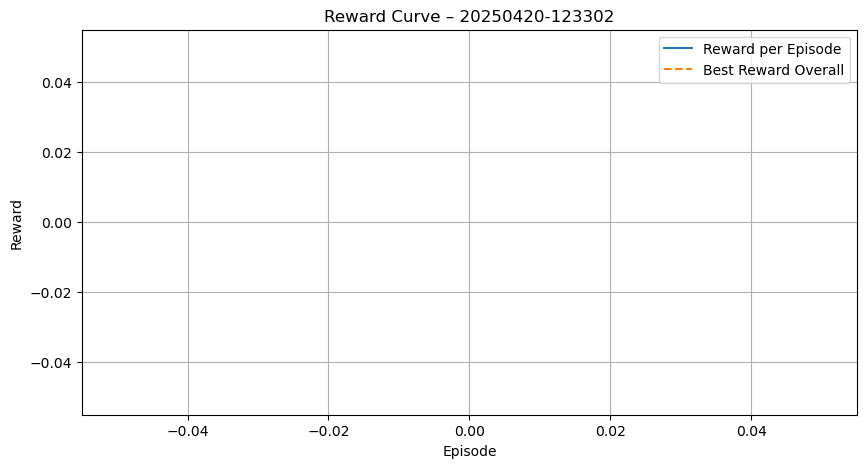

Saved plots to: images/20250420-123302_reward_plot_20250420_1307.png


In [ ]:
# ========== Plot and Save Curves ==========
Path("images").mkdir(exist_ok=True)
model_name = Path(log_dir).name
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Reward Plot
plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Reward per Episode")
plt.plot([max(rewards[:i+1]) for i in range(len(rewards))], linestyle='--', label="Best Reward Overall")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Curve – {model_name}")
plt.grid(True)
plt.legend()
reward_path = f"images/{model_name}_reward_plot_{timestamp}.png"
plt.savefig(reward_path)
plt.show()

# Loss Plot
if losses:
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label="Loss per Train Step")
    plt.xlabel("Train Step")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    loss_path = f"images/{model_name}_loss_plot_{timestamp}.png"
    plt.savefig(loss_path)
    plt.show()

print(f"Saved plots to: {reward_path}")

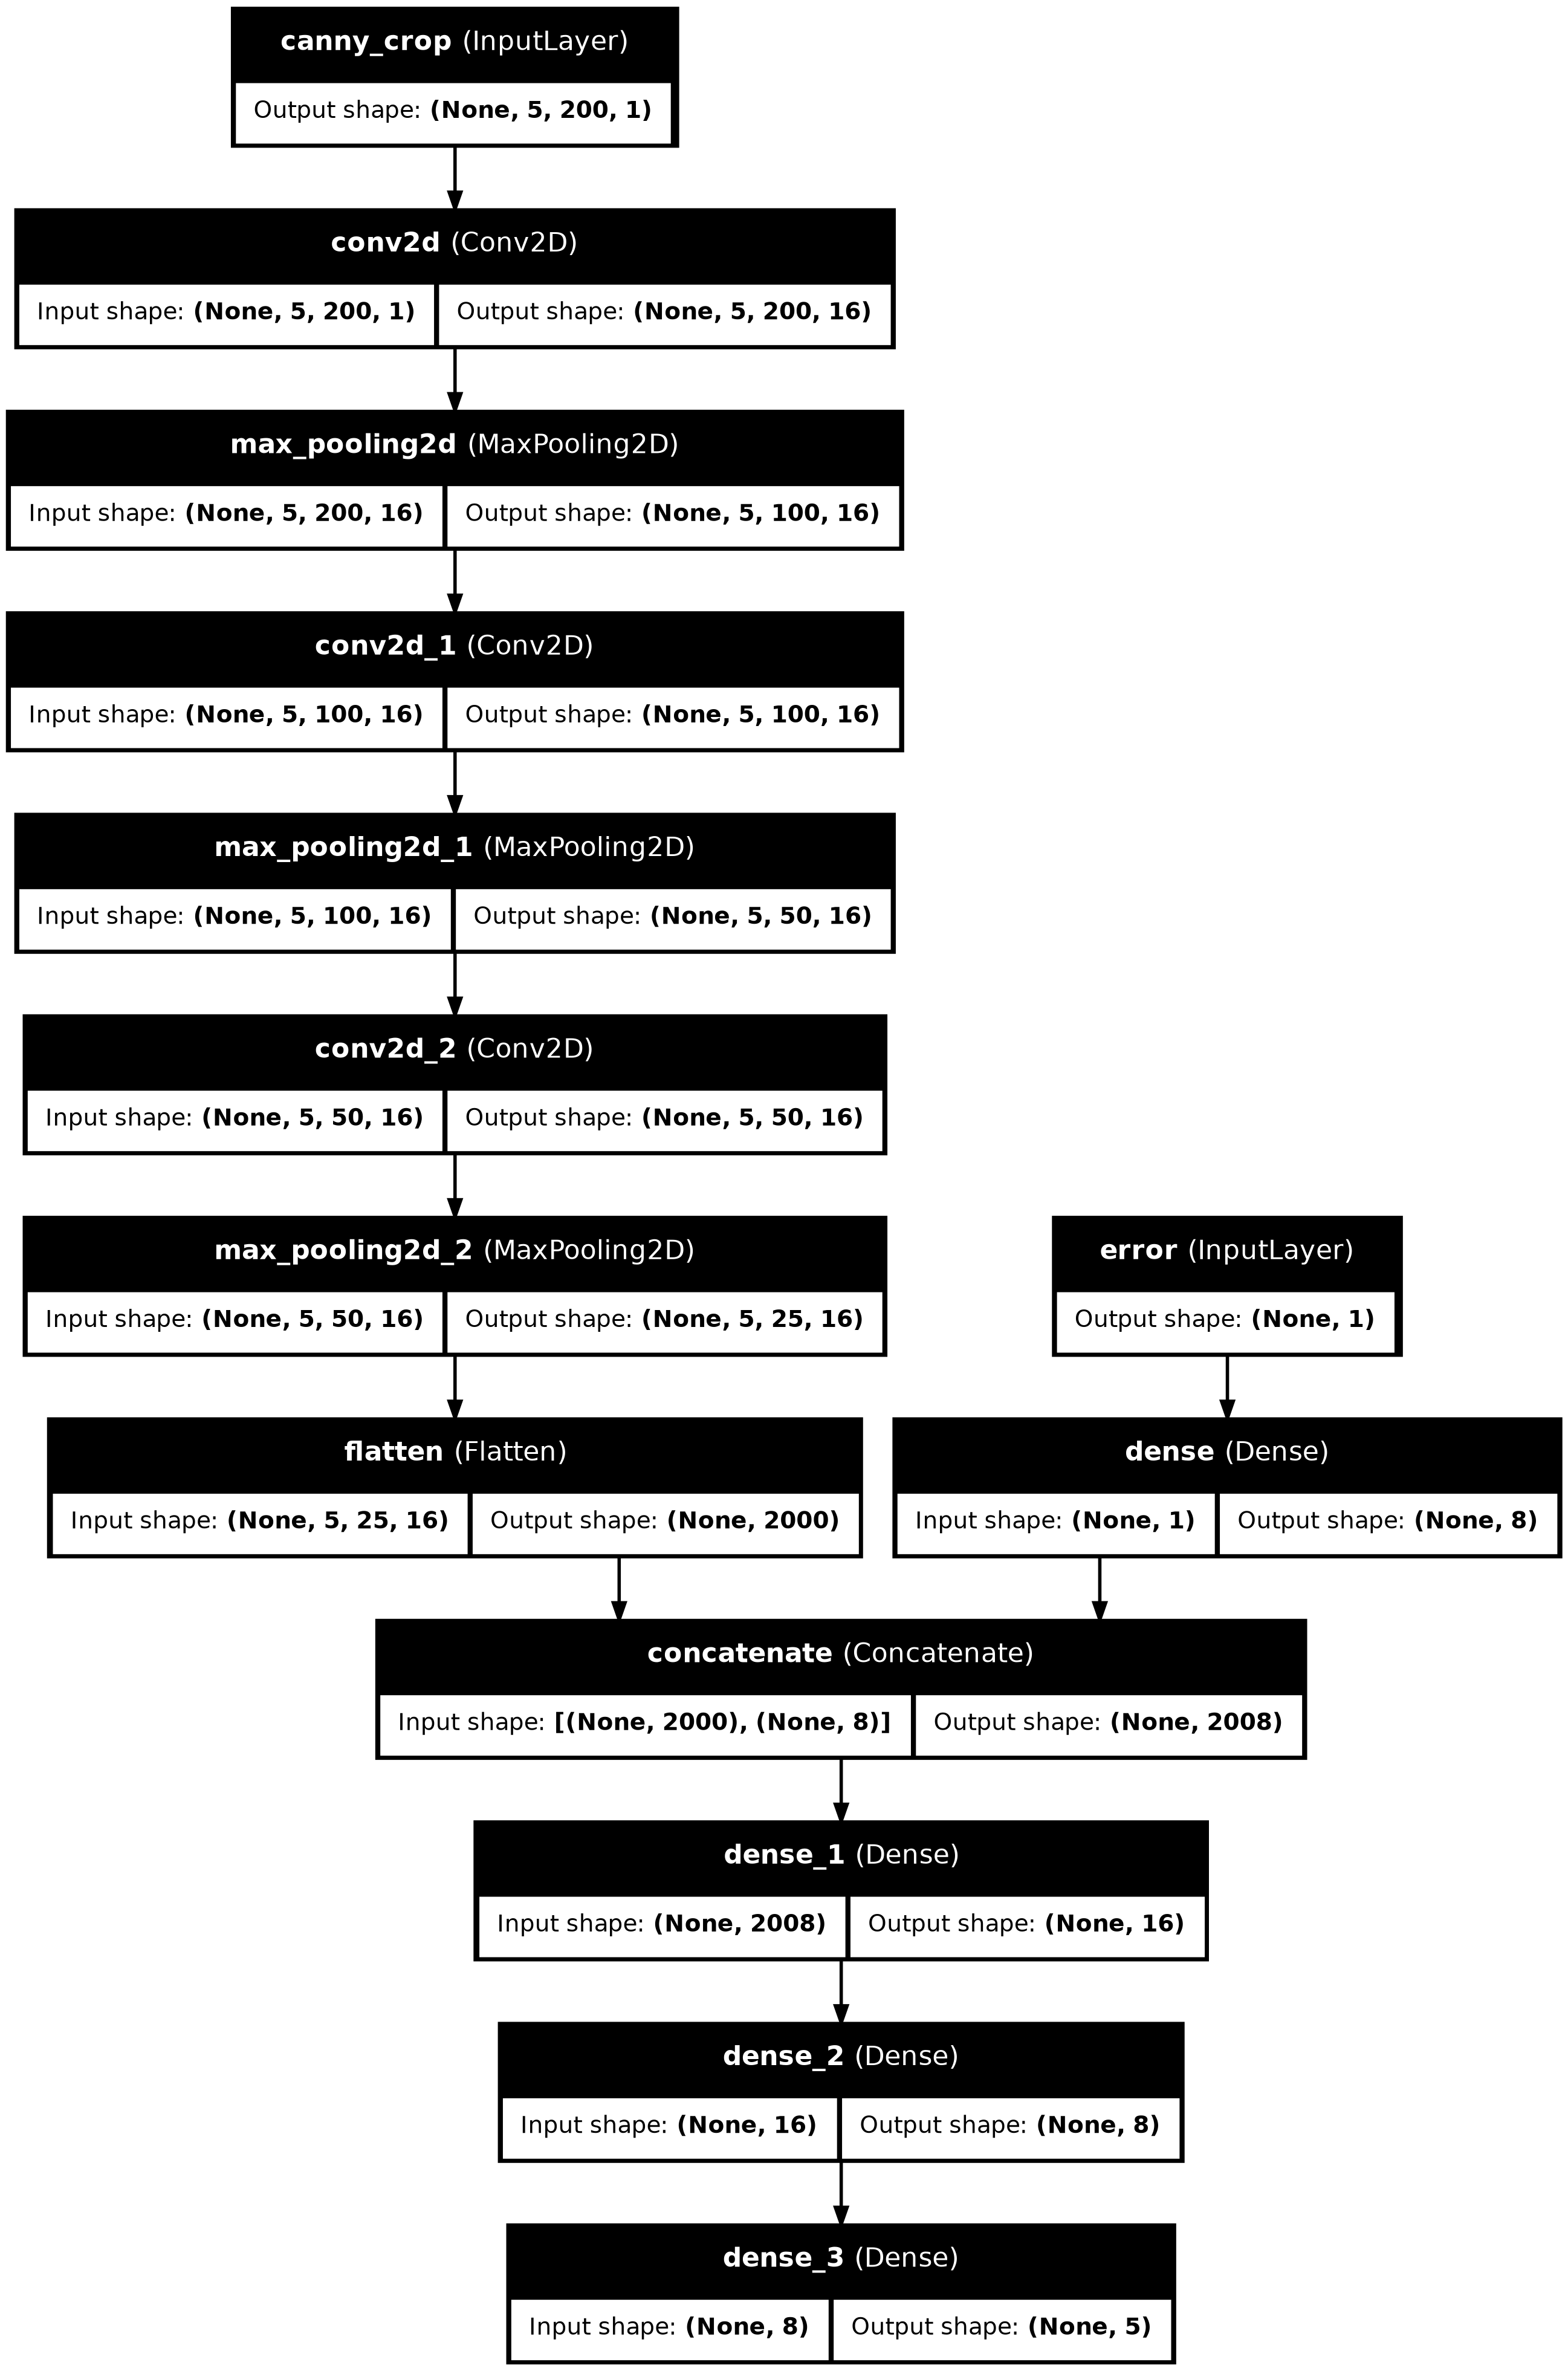

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file=f'images/{model_name}_model_plot_{timestamp}.png', show_shapes=True, show_layer_names=True)
